In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
notebook_dir = Path.cwd()

candidate_paths = [
    notebook_dir / "data/raw/MBA.csv",
    notebook_dir.parent / "data/raw/MBA.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find MBA.csv. Checked: {', '.join(str(path) for path in candidate_paths)}"
    )

df = pd.read_csv(data_path)

print("Shape:", df.shape)

df.head()

Shape: (6194, 10)


,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [6]:
print("="*50)
print("DATASET INFO")
print("="*50)

df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   str    
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   str    
 5   race            4352 non-null   str    
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   str    
 9   admission       1000 non-null   str    
dtypes: bool(1), float64(3), int64(1), str(5)
memory usage: 441.7 KB


In [7]:
print("="*50)
print("NUMERICAL SUMMARY")
print("="*50)

df.describe()

NUMERICAL SUMMARY


,application_id,gpa,gmat,work_exp
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


In [8]:
print("="*50)
print("MISSING VALUES")
print("="*50)

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    "Missing %",
    ascending=False
)

MISSING VALUES


,Missing Count,Missing %
admission,5194,83.86
race,1842,29.74
gender,0,0.00
application_id,0,0.00
gpa,0,0.00
international,0,0.00
major,0,0.00
gmat,0,0.00
work_exp,0,0.00
work_industry,0,0.00


In [9]:
df["admission_clean"] = df["admission"].fillna("Deny")

df["admission_clean"].value_counts()

admission_clean
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

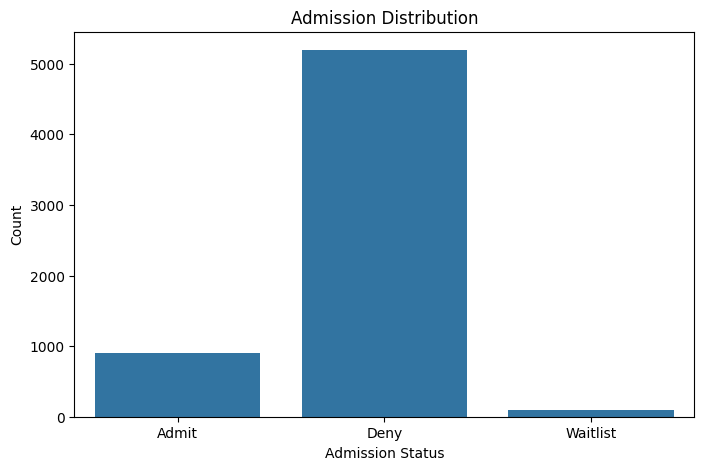

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="admission_clean"
)

plt.title("Admission Distribution")
plt.xlabel("Admission Status")
plt.ylabel("Count")

plt.show()

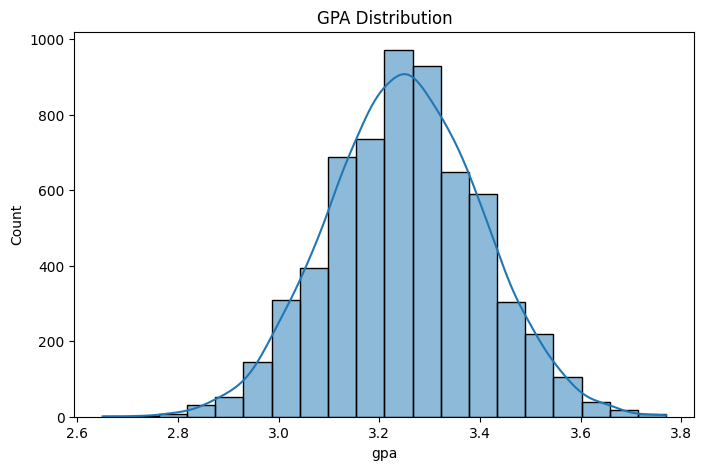

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["gpa"],
    bins=20,
    kde=True
)

plt.title("GPA Distribution")

plt.show()

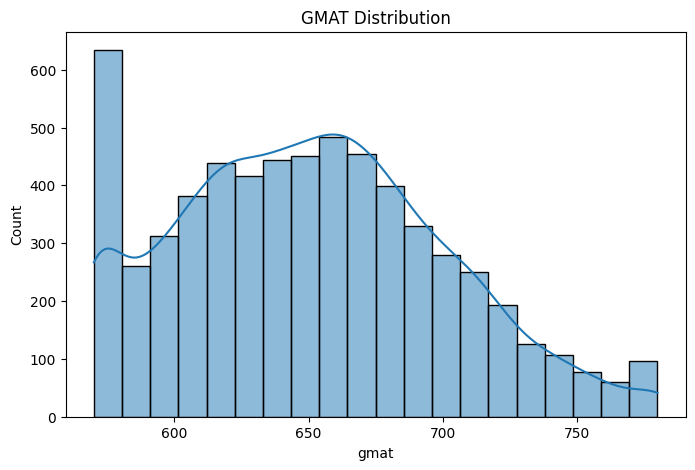

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["gmat"],
    bins=20,
    kde=True
)

plt.title("GMAT Distribution")

plt.show()

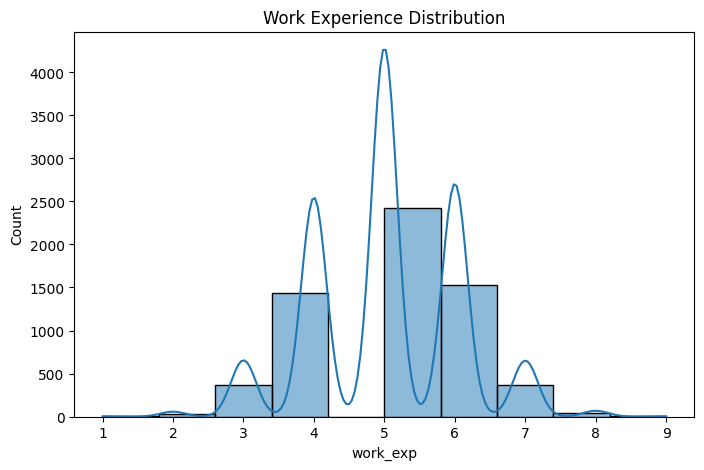

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["work_exp"],
    bins=10,
    kde=True
)

plt.title("Work Experience Distribution")

plt.show()

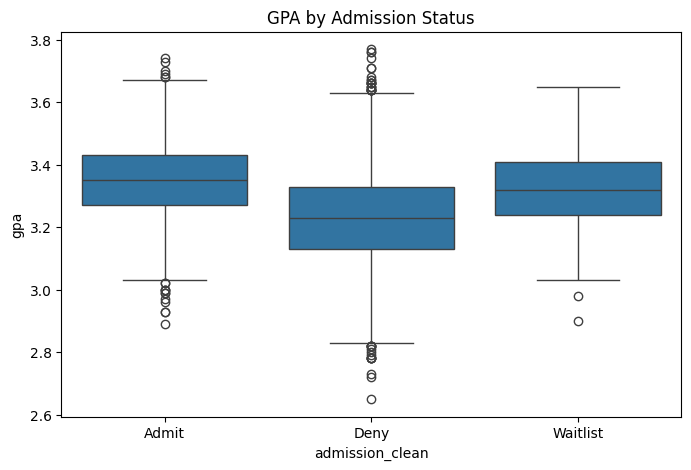

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="admission_clean",
    y="gpa"
)

plt.title("GPA by Admission Status")

plt.show()

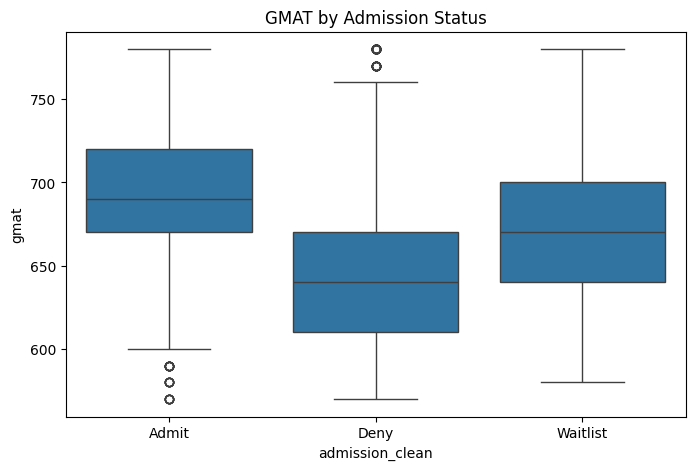

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="admission_clean",
    y="gmat"
)

plt.title("GMAT by Admission Status")

plt.show()

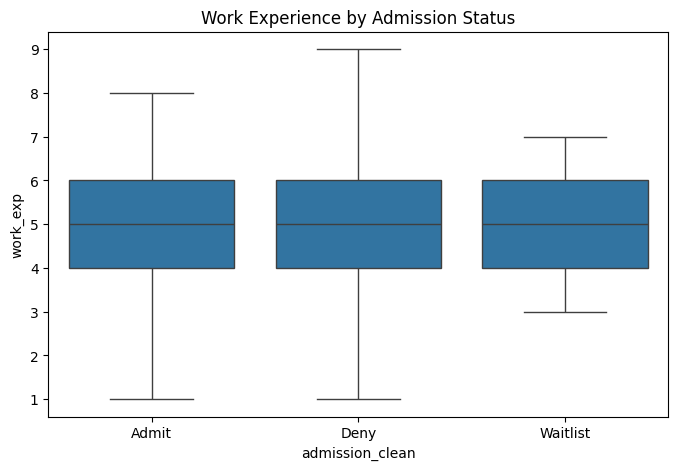

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="admission_clean",
    y="work_exp"
)

plt.title("Work Experience by Admission Status")

plt.show()

admission_clean     Admit      Deny  Waitlist
gender                                       
Female           0.199911  0.777876  0.022212
Male             0.114126  0.873193  0.012681


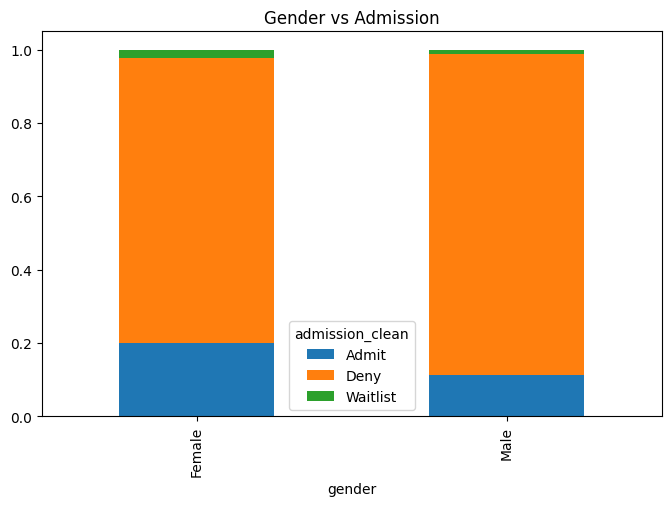

In [17]:
gender_admission = pd.crosstab(
    df["gender"],
    df["admission_clean"],
    normalize="index"
)

print(gender_admission)

gender_admission.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Gender vs Admission")

plt.show()

admission_clean     Admit      Deny  Waitlist
major                                        
Business         0.146899  0.841132  0.011970
Humanities       0.147924  0.835550  0.016526
STEM             0.140267  0.840000  0.019733


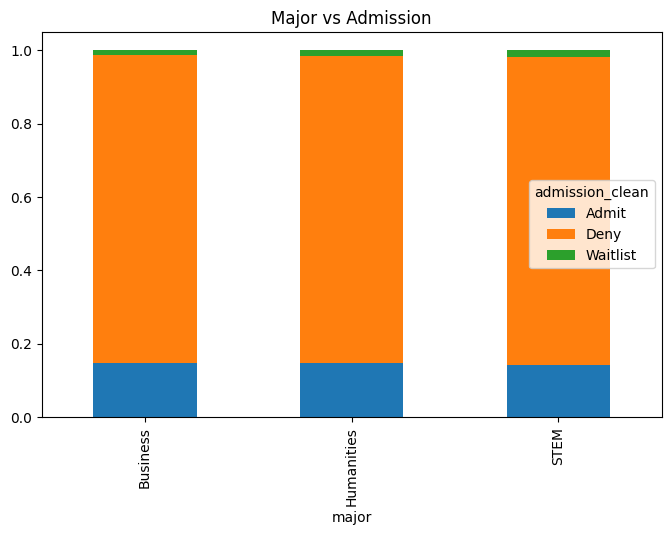

In [19]:
major_admission = pd.crosstab(
    df["major"],
    df["admission_clean"],
    normalize="index"
)

print(major_admission)

major_admission.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Major vs Admission")

plt.show()

admission_clean     Admit      Deny  Waitlist
international                                
False            0.142923  0.840993  0.016085
True             0.150923  0.832790  0.016287


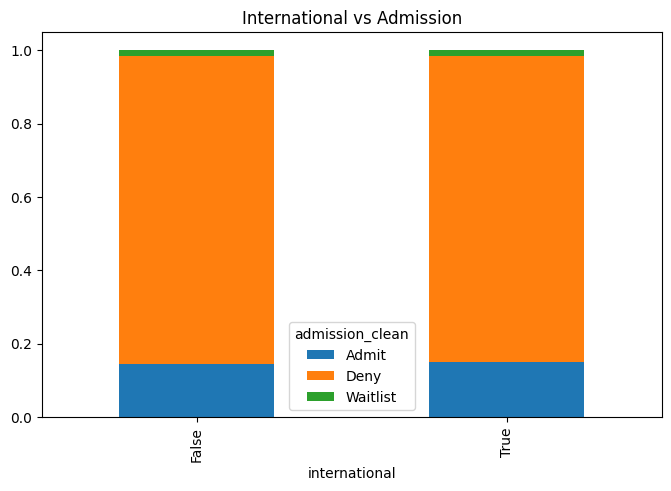

In [20]:
international_admission = pd.crosstab(
    df["international"],
    df["admission_clean"],
    normalize="index"
)

print(international_admission)

international_admission.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("International vs Admission")

plt.show()

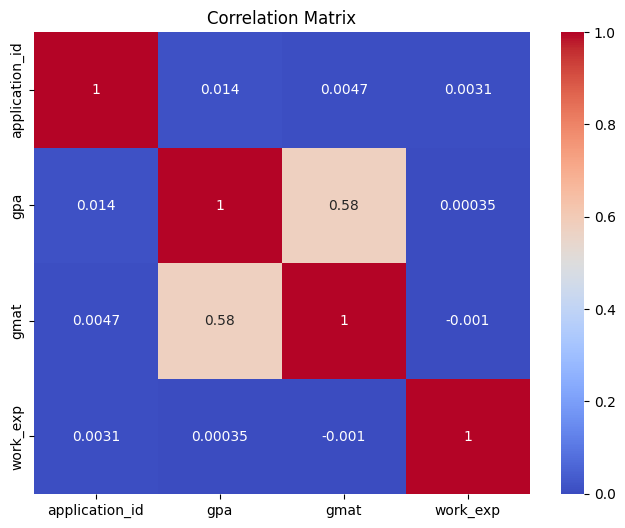

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "eda_output.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"EDA dataset saved to {output_path.resolve()}")

EDA dataset saved to C:\Users\ASUS\OneDrive\Documents\Kuliah\Semester 6\Sistem Pendukung Keputusan\Tugas 4\University Admission DSS\data\processed\eda_output.csv


: 